In [43]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from pydantic import SecretStr,BaseModel , Field 
from typing import TypedDict,NotRequired,Annotated, Literal
from langgraph.graph import StateGraph, START, END
import operator

from dotenv import load_dotenv

load_dotenv()

True

In [44]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash-lite",
    api_key = SecretStr(os.environ["GOOGLE_API_KEY"]),
)

In [45]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field (..., description="The sentiment of the text, either 'positive' or 'negative'.")

In [46]:
class DiagnosisSchema(BaseModel) :
    issue_type : Literal["UX","Performance","Bug","Support","Other"] = Field(..., description="The type of issue identified in the review.")
    tone : Literal['angry','frustrated','disappointment','calm'] = Field(..., description="The tone of the review, which can be 'angry', 'frustrated', 'disappointment', or 'calm'.")

    urgency : Literal['high','medium','low'] = Field(..., description="The urgency of the issue, which can be 'high', 'medium', or 'low'. This field is optional and may not be present in all cases.")

In [47]:
llm_with_structured_output = llm.with_structured_output(SentimentSchema)
llm_with_structured_output_diagnosis = llm.with_structured_output(DiagnosisSchema)



In [48]:
class  ReviewState(TypedDict):
    review : str
    sentiment : NotRequired[Literal["positive", "negative"]]
    diagnosis : NotRequired[dict]
    response : NotRequired[str]


In [49]:
def find_sentiment(state: ReviewState):
    prompt = f"For the following review find out the sentiment of the review. The sentiment can be either 'positive' or 'negative'.\n\nReview: {state['review']}"

    sentiment_result = llm_with_structured_output.invoke(prompt)
    state["sentiment"] = sentiment_result.sentiment
    return {
        'sentiment' : sentiment_result.sentiment
    }

In [50]:
def check_sentiment(state : ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    sentiment = state.get("sentiment")
    if sentiment == "positive":
        return "positive_response"
    elif sentiment == "negative":
        return "run_diagnosis"
    else:
        raise ValueError("Sentiment not found in state.")

In [51]:
def positive_response(state: ReviewState):
    prompt = f"Write a positive response to the following review:\n\nReview: {state['review']}"
    response = llm.invoke(prompt).text
    return {
        'response' : response
    }

In [52]:
def run_diagnosis(state:ReviewState):
    prompt = f"""Diagnosis this negative review: \n\n{state['review']}\n
    Return issue_type , tone and urgency
"""

    llm_with_structured_output_diagnosis = llm.with_structured_output(DiagnosisSchema)
    respnse = llm_with_structured_output_diagnosis.invoke(prompt)
    return {
        'diagnosis' : respnse.model_dump()
    }

In [53]:
def negative_response(state: ReviewState):
    diagnosis = state.get("diagnosis", {})
    prompt = f"Write a response to the following negative review:\n\nReview: {state['review']}\n\nDiagnosis: {diagnosis}. Write an empathetic response to the user."
    response = llm.invoke(prompt).text
    return {
        'response': response
    }

In [54]:
graph = StateGraph(ReviewState)
    
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("check_sentiment",check_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)
graph.add_node("positive_response",positive_response)


graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges('find_sentiment',check_sentiment)


graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)
graph.add_edge("positive_response",END)

workflow = graph.compile()

final_output = workflow.invoke({"review": "The product is terrible even its software has many bugs and the support team is not helpful at all."})
final_output



{'review': 'The product is terrible even its software has many bugs and the support team is not helpful at all.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': 'Dear [Customer Name],\n\nThank you for reaching out, and I am truly sorry for the frustrating experience you’ve had with both our product and our support team. I completely understand why you are angry—dealing with software bugs and then not getting the help you needed is deeply frustrating, and this is certainly not the level of service we strive to provide. \n\nWe take these software issues very seriously, and I want to personally ensure this gets sorted out for you right away. \n\nTo help us resolve this urgently, could you please reply with a few details about the bugs you are encountering? \n\n*   What specific errors or issues are you seeing?\n*   What device/operating system are you using?\n\nAs a priority, I am escalating your case directly to our senior 

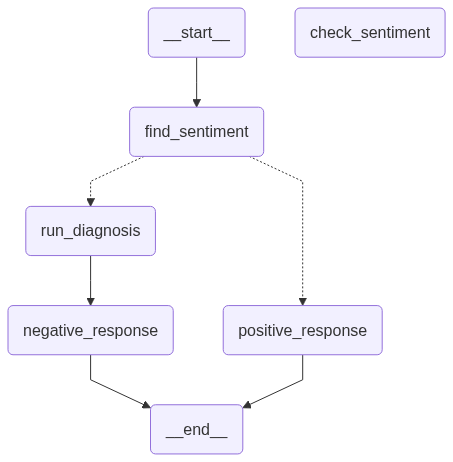

In [55]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())